<a href="https://colab.research.google.com/github/KeerthanaJagadesh/Hypernymy-in-Word-Embeddings-BERT-vs.-GloVe/blob/main/AdvTopics_Term_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Topics and Computational Media Sciences Term Paper — Do Word Embeddings Encode Hypernymy? A Controlled Comparison of Contextual (BERT) and Static (GloVe) Representations on the WordNet Animal Domain

**Author:** Keerthana Jagadesh (1774724)

---

## PHASE 1 — Setup & Environment

### 1.1 — Create Project Directory & Install Dependencies

In [1]:
# Use local Colab storage (no Drive mount needed)
import os

DRIVE_BASE = "/content/Hypernymy_Project"

# Create subdirectories
for subdir in ["data", "embeddings", "results"]:
    os.makedirs(os.path.join(DRIVE_BASE, subdir), exist_ok=True)

print(f"Project directory: {DRIVE_BASE}")
print("Subdirectories created successfully.")

Project directory: /content/Hypernymy_Project
Subdirectories created successfully.


In [2]:
# Install required packages
!pip install -q transformers gensim nltk scipy scikit-learn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 31.6 MB/s eta 0:00:00


### 1.2 — Import Libraries & Set Seeds

In [3]:
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModel
import gensim.downloader as api
from scipy import stats
from sklearn.decomposition import PCA

import nltk
nltk.download('wordnet', quiet=True)
from nltk.corpus import wordnet as wn

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU")
print(f"PyTorch: {torch.__version__}")

GPU: Tesla T4
Memory: 15.6 GB
PyTorch: 2.11.0+cu128


### 1.3 — Helper Functions

In [4]:
def cosine_sim(a, b):
    """Cosine similarity between two vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def bootstrap_ci(values, n_boot=1000, ci=95):
    """Bootstrap confidence interval for the mean."""
    values = np.asarray(values)
    means = [np.mean(np.random.choice(values, size=len(values), replace=True))
             for _ in range(n_boot)]
    lo, hi = np.percentile(means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi


def cohens_d(a, b):
    """Cohen's d effect size."""
    a, b = np.asarray(a), np.asarray(b)
    pooled_std = np.sqrt(((len(a) - 1) * a.std(ddof=1) ** 2 + (len(b) - 1) * b.std(ddof=1) ** 2)
                          / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled_std


print("Helper functions defined.")

Helper functions defined.


---
## PHASE 2 — Data Collection

### 2.1 — Extract Hypernym–Hyponym Pairs from WordNet

In [5]:
pairs = []

# ── Get all animal synsets (this is our sub-domain) ──
animal_root = wn.synset('animal.n.01')

def get_hyponym_pairs(synset, pairs, max_depth=4, depth=0):
    if depth >= max_depth:
        return
    # sort hyponyms by name so traversal order is deterministic across runs
    # (Python's hash randomization otherwise makes synset.hyponyms() order vary per process)
    for hyponym in sorted(synset.hyponyms(), key=lambda s: s.lemma_names()[0]):
        # hyponym is the SPECIFIC word, synset is the GENERAL word
        specific = hyponym.lemma_names()[0].replace('_', ' ')
        general = synset.lemma_names()[0].replace('_', ' ')
        pairs.append({'specific': specific, 'general': general, 'depth': depth})
        get_hyponym_pairs(hyponym, pairs, max_depth, depth + 1)

get_hyponym_pairs(animal_root, pairs)

df = pd.DataFrame(pairs)
df = df.drop_duplicates(subset=['specific', 'general'])
df = df.sort_values(['depth', 'general', 'specific']).reset_index(drop=True)

# ── Save ──
PAIRS_PATH = os.path.join(DRIVE_BASE, 'data/animal_pairs.csv')
df.to_csv(PAIRS_PATH, index=False)

print(f"Total pairs collected: {len(df)}")
print(f"Unique specific words: {df['specific'].nunique()}")
print(f"Unique general words:  {df['general'].nunique()}")
print(f"\nDepth distribution:")
print(df['depth'].value_counts().sort_index())
print(f"\nSaved to {PAIRS_PATH}")

Total pairs collected: 514
Unique specific words: 506
Unique general words:  97

Depth distribution:
depth
0     47
1     71
2    150
3    246
Name: count, dtype: int64

Saved to /content/Hypernymy_Project/data/animal_pairs.csv


In [ ]:
# Quick preview
df.head(10)

,specific,general,depth
0,acrodont,animal,0
1,adult,animal,0
2,biped,animal,0
3,captive,animal,0
4,chordate,animal,0
5,creepy-crawly,animal,0
6,critter,animal,0
7,darter,animal,0
8,domestic animal,animal,0
9,embryo,animal,0


---
## PHASE 3 — Embedding Generation

### 3.1 — Model A: BERT Embeddings (Contextual, 768-d)

In [6]:
# ── Load pairs ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))

# Every distinct word/phrase that appears in either column needs an embedding
words = sorted(set(df['specific']).union(set(df['general'])))
print(f"Unique words/phrases to embed: {len(words)}")

# ── Load BERT ──
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()
model = model.to(DEVICE)
print(f"Loaded {MODEL_NAME} on {DEVICE}")

Unique words/phrases to embed: 507


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded bert-base-uncased on cuda


In [7]:
def embed_bert(word):
    """Embed a word/phrase with BERT. Mean-pools subword tokens (excl. [CLS]/[SEP])."""
    inputs = tokenizer(word, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.last_hidden_state: [1, num_tokens, hidden_size]
    # drop [CLS]/[SEP] (first and last token) before averaging
    token_vecs = outputs.last_hidden_state[0][1:-1]
    return token_vecs.mean(dim=0).cpu().numpy()

# ── Generate embeddings ──
bert_embeddings = {}
for i, word in enumerate(words):
    bert_embeddings[word] = embed_bert(word)
    if (i + 1) % 50 == 0 or (i + 1) == len(words):
        print(f"  embedded {i + 1}/{len(words)}")

# ── Save ──
BERT_PATH = os.path.join(DRIVE_BASE, 'embeddings/word_embeddings.pkl')
with open(BERT_PATH, 'wb') as f:
    pickle.dump(bert_embeddings, f)

print(f"\nSaved {len(bert_embeddings)} BERT embeddings to {BERT_PATH}")
print(f"Each embedding has {len(next(iter(bert_embeddings.values())))} dimensions")

  embedded 50/507
  embedded 100/507
  embedded 150/507
  embedded 200/507
  embedded 250/507
  embedded 300/507
  embedded 350/507
  embedded 400/507
  embedded 450/507
  embedded 500/507
  embedded 507/507

Saved 507 BERT embeddings to /content/Hypernymy_Project/embeddings/word_embeddings.pkl
Each embedding has 768 dimensions


### 3.2 — Model B: GloVe Embeddings (Static, 300-d)

In [8]:
# ── Load pairs ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))
words = sorted(set(df['specific']).union(set(df['general'])))
print(f"Unique words/phrases to embed: {len(words)}")

# ── Load GloVe ──
print("Loading GloVe vectors (glove-wiki-gigaword-300)... this downloads ~376MB on first run.")
glove = api.load('glove-wiki-gigaword-300')

# ── Generate embeddings ──
glove_embeddings = {}
missing = []

for word in words:
    # GloVe has no multi-word phrase vectors, so for a phrase like
    # "young mammal" we average the vectors of its individual tokens
    tokens = word.lower().split()
    token_vecs = [glove[t] for t in tokens if t in glove]
    if not token_vecs:
        missing.append(word)
        continue
    glove_embeddings[word] = np.mean(token_vecs, axis=0)

print(f"\nCovered: {len(glove_embeddings)}/{len(words)} words")
print(f"Missing (no GloVe vector found for any token): {len(missing)}")
if missing:
    print("  examples:", missing[:15])

# ── Save ──
GLOVE_PATH = os.path.join(DRIVE_BASE, 'embeddings/glove_embeddings.pkl')
with open(GLOVE_PATH, 'wb') as f:
    pickle.dump(glove_embeddings, f)

print(f"\nSaved to {GLOVE_PATH}")

Unique words/phrases to embed: 507
Loading GloVe vectors (glove-wiki-gigaword-300)... this downloads ~376MB on first run.
[==================================================] 100.0% 376.1/376.1MB downloaded

Covered: 409/507 words
Missing (no GloVe vector found for any token): 98
  examples: ['Amniota', 'Astrophyton muricatum', 'Chrysaora quinquecirrha', 'Diapsida', 'Ibero-mesornis', 'Ichyostega', 'Merostomata', 'Sennenhunde', 'Shih-Tzu', 'Sinornis', 'abortus', 'acanthocephalan', 'acarine', 'acrodont', 'anapsid']

Saved to /content/Hypernymy_Project/embeddings/glove_embeddings.pkl


---
## PHASE 4 — Embedding Analysis (BERT)

### 4.1 — Cosine Similarity: True Pairs vs Random Pairs

In [36]:
# ── Load data ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))

with open(os.path.join(DRIVE_BASE, 'embeddings/word_embeddings.pkl'), 'rb') as f:
    embeddings = dict(pickle.load(f))

# ── Similarity of TRUE hypernym/hyponym pairs ──
df['similarity'] = [
    cosine_sim(embeddings[row.specific], embeddings[row.general])
    for row in df.itertuples()
]

# ── Similarity of RANDOM (non-hypernym) pairs, as a control group ──
random.seed(SEED)
all_words = list(embeddings.keys())
true_pairs = set(zip(df['specific'], df['general']))

random_sims = []
attempts = 0
while len(random_sims) < len(df) and attempts < len(df) * 20:
    w1, w2 = random.sample(all_words, 2)
    attempts += 1
    if (w1, w2) in true_pairs or (w2, w1) in true_pairs:
        continue
    random_sims.append(cosine_sim(embeddings[w1], embeddings[w2]))

random_sims = np.array(random_sims)

print("=== Cosine similarity: TRUE hypernym pairs vs RANDOM pairs ===")
print(f"True pairs   -> mean: {df['similarity'].mean():.3f}  std: {df['similarity'].std():.3f}")
print(f"Random pairs -> mean: {random_sims.mean():.3f}  std: {random_sims.std():.3f}")



=== Cosine similarity: TRUE hypernym pairs vs RANDOM pairs ===
True pairs   -> mean: 0.508  std: 0.166
Random pairs -> mean: 0.426  std: 0.122


### 4.2 — Offset Consistency

In [31]:
# ── Offset consistency: is "general - specific" a consistent direction? ──
diffs = np.array([
    embeddings[row.general] - embeddings[row.specific]
    for row in df.itertuples()
])
mean_diff = diffs.mean(axis=0)
df['offset_consistency'] = [cosine_sim(d, mean_diff) for d in diffs]

print("=== Offset consistency (does 'general - specific' point the same way?) ===")
print(f"mean: {df['offset_consistency'].mean():.3f}  std: {df['offset_consistency'].std():.3f}")
print("(closer to 1.0 = a consistent hypernym direction exists; closer to 0 = no consistent direction)")

=== Offset consistency (does 'general - specific' point the same way?) ===
mean: 0.209  std: 0.208
(closer to 1.0 = a consistent hypernym direction exists; closer to 0 = no consistent direction)


### 4.3 — Similarity by Depth

In [37]:
print("=== Similarity by depth ===")
print(df.groupby('depth')['similarity'].agg(['mean', 'std', 'count']))

# One-way ANOVA: does depth affect similarity?
groups = [g['similarity'].values for _, g in df.groupby('depth')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA across depth 0-3: F={f_stat:.3f}, p={p_val:.3f}")


=== Similarity by depth ===
           mean       std  count
depth                           
0      0.508214  0.142786     47
1      0.459011  0.178579     71
2      0.512983  0.148479    150
3      0.519204  0.175665    246

One-way ANOVA across depth 0-3: F=2.487, p=0.060


### 4.4 — Plots: True vs Random & Offset Consistency

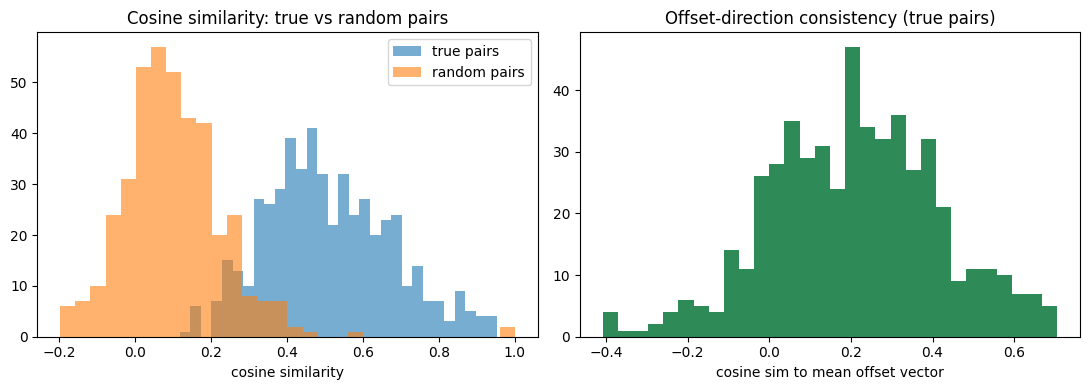

Saved results/pair_analysis.csv and results/similarity_plots.png


In [34]:
# ── Save pair analysis ──
df.to_csv(os.path.join(DRIVE_BASE, 'results/pair_analysis.csv'), index=False)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['similarity'], bins=30, alpha=0.6, label='true pairs')
axes[0].hist(random_sims, bins=30, alpha=0.6, label='random pairs')
axes[0].set_title('Cosine similarity: true vs random pairs')
axes[0].set_xlabel('cosine similarity')
axes[0].legend()

axes[1].hist(df['offset_consistency'], bins=30, color='seagreen')
axes[1].set_title('Offset-direction consistency (true pairs)')
axes[1].set_xlabel('cosine sim to mean offset vector')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'results/similarity_plots.png'), dpi=150)
plt.show()
print("Saved results/pair_analysis.csv and results/similarity_plots.png")

---
## PHASE 5 — Model Comparison (BERT vs GloVe)

### 5.1 — Controlled Comparison: Welch's t-test, Cohen's d, Bootstrap CIs

In [38]:
# ── Load data ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))

with open(os.path.join(DRIVE_BASE, 'embeddings/word_embeddings.pkl'), 'rb') as f:
    bert = dict(pickle.load(f))
with open(os.path.join(DRIVE_BASE, 'embeddings/glove_embeddings.pkl'), 'rb') as f:
    glove = dict(pickle.load(f))

MODELS = {'BERT (contextual)': bert, 'GloVe (static)': glove}

random.seed(SEED)

# ── Run comparison ──
results_rows = []
plot_data = {}

for model_name, emb in MODELS.items():
    covered = df[df['specific'].isin(emb) & df['general'].isin(emb)].copy()
    coverage_pct = 100 * len(covered) / len(df)

    covered['similarity'] = [
        cosine_sim(emb[row.specific], emb[row.general])
        for row in covered.itertuples()
    ]

    all_words = list(emb.keys())
    true_pairs = set(zip(covered['specific'], covered['general']))
    random_sims = []
    attempts = 0
    while len(random_sims) < len(covered) and attempts < len(covered) * 30:
        w1, w2 = random.sample(all_words, 2)
        attempts += 1
        if (w1, w2) in true_pairs or (w2, w1) in true_pairs:
            continue
        random_sims.append(cosine_sim(emb[w1], emb[w2]))
    random_sims = np.array(random_sims)

    diffs = np.array([
        emb[row.general] - emb[row.specific]
        for row in covered.itertuples()
    ])
    diff_norms = np.linalg.norm(diffs, axis=1)
    n_degenerate = int((diff_norms == 0).sum())
    # a zero-norm diff means specific and general got IDENTICAL vectors,
    # which for GloVe happens when a phrase's modifier word is out-of-vocabulary
    nonzero_diffs = diffs[diff_norms > 0]
    mean_diff = nonzero_diffs.mean(axis=0)
    offset_consistency = np.array([cosine_sim(d, mean_diff) for d in nonzero_diffs])

    t_stat, p_val = stats.ttest_ind(covered['similarity'], random_sims, equal_var=False)
    d = cohens_d(covered['similarity'].values, random_sims)
    true_ci = bootstrap_ci(covered['similarity'].values)
    random_ci = bootstrap_ci(random_sims)

    results_rows.append({
        'model': model_name,
        'pairs_covered': len(covered),
        'coverage_pct': round(coverage_pct, 1),
        'true_sim_mean': round(covered['similarity'].mean(), 3),
        'true_sim_ci_lo': round(true_ci[0], 3),
        'true_sim_ci_hi': round(true_ci[1], 3),
        'random_sim_mean': round(random_sims.mean(), 3),
        'random_sim_ci_lo': round(random_ci[0], 3),
        'random_sim_ci_hi': round(random_ci[1], 3),
        't_stat': round(t_stat, 2),
        'p_value': p_val,
        'cohens_d': round(d, 3),
        'offset_consistency_mean': round(offset_consistency.mean(), 3),
        'offset_consistency_std': round(offset_consistency.std(), 3),
        'n_degenerate_pairs': n_degenerate,
    })

    plot_data[model_name] = {
        'true': covered['similarity'].values,
        'random': random_sims,
    }

results_df = pd.DataFrame(results_rows)
results_df.to_csv(os.path.join(DRIVE_BASE, 'results/model_comparison.csv'), index=False)

print('=== Controlled comparison: BERT vs GloVe on hypernymy pairs ===\n')
for row in results_rows:
    print(f'--- {row["model"]} ---')
    print(f'  Coverage: {row["pairs_covered"]} pairs ({row["coverage_pct"]}%)')
    print(f'  True pairs similarity:   {row["true_sim_mean"]}  95% CI [{row["true_sim_ci_lo"]}, {row["true_sim_ci_hi"]}]')
    print(f'  Random pairs similarity: {row["random_sim_mean"]}  95% CI [{row["random_sim_ci_lo"]}, {row["random_sim_ci_hi"]}]')
    print(f'  Welch\'s t-test: t={row["t_stat"]}, p={row["p_value"]:.2e}  (Cohen\'s d={row["cohens_d"]})')
    print(f'  Offset consistency: {row["offset_consistency_mean"]} (std {row["offset_consistency_std"]})')
    if row['n_degenerate_pairs']:
        print(f'  Degenerate (zero-diff) pairs excluded from offset consistency: {row["n_degenerate_pairs"]}')
    print()

=== Controlled comparison: BERT vs GloVe on hypernymy pairs ===

--- BERT (contextual) ---
  Coverage: 514 pairs (100.0%)
  True pairs similarity:   0.508  95% CI [0.494, 0.522]
  Random pairs similarity: 0.426  95% CI [0.415, 0.436]
  Welch's t-test: t=9.06, p=7.27e-19  (Cohen's d=0.565)
  Offset consistency: 0.209 (std 0.208)

--- GloVe (static) ---
  Coverage: 397 pairs (77.2%)
  True pairs similarity:   0.367  95% CI [0.337, 0.398]
  Random pairs similarity: 0.103  95% CI [0.091, 0.117]
  Welch's t-test: t=16.15, p=1.93e-48  (Cohen's d=1.147)
  Offset consistency: 0.224 (std 0.207)
  Degenerate (zero-diff) pairs excluded from offset consistency: 23



### 5.2 — Results Summary Table

In [14]:
results_df[['model', 'pairs_covered', 'coverage_pct', 'true_sim_mean',
            'random_sim_mean', 'cohens_d', 'offset_consistency_mean']]

,model,pairs_covered,coverage_pct,true_sim_mean,random_sim_mean,cohens_d,offset_consistency_mean
0,BERT (contextual),514,100.0,0.508,0.426,0.565,0.209
1,GloVe (static),397,77.2,0.367,0.103,1.147,0.224


### 5.3 — Plot: Side-by-Side Histograms

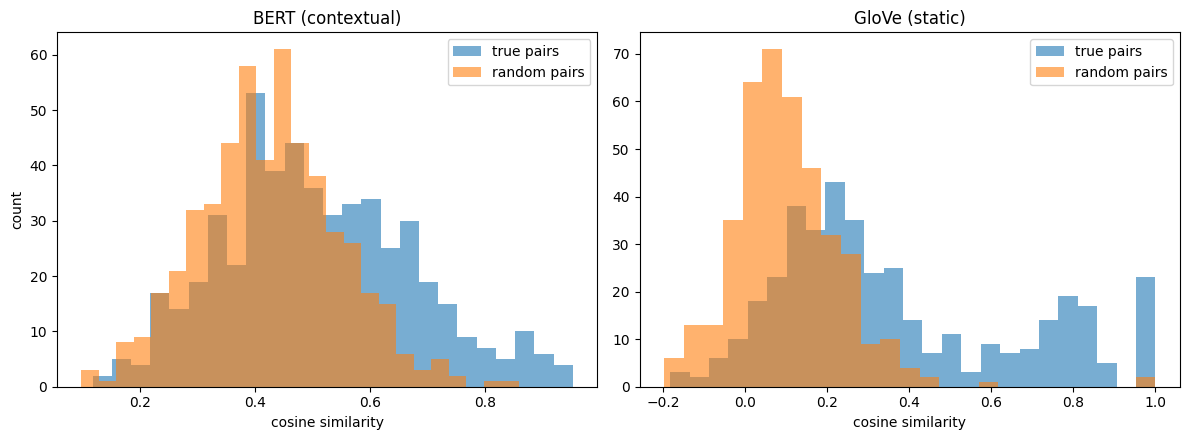

Saved results/model_comparison_plot.png


In [15]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4.5))
if len(MODELS) == 1:
    axes = [axes]
for ax, (model_name, data) in zip(axes, plot_data.items()):
    ax.hist(data['true'], bins=25, alpha=0.6, label='true pairs')
    ax.hist(data['random'], bins=25, alpha=0.6, label='random pairs')
    ax.set_title(model_name)
    ax.set_xlabel('cosine similarity')
    ax.legend()
axes[0].set_ylabel('count')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'results/model_comparison_plot.png'), dpi=150)
plt.show()
print('Saved results/model_comparison_plot.png')

---
## PHASE 6 — Qualitative Analysis

### 6.1 — Case Studies: Best, Worst & Disagreement Pairs

In [16]:
# ── Load data ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))

with open(os.path.join(DRIVE_BASE, 'embeddings/word_embeddings.pkl'), 'rb') as f:
    bert = dict(pickle.load(f))
with open(os.path.join(DRIVE_BASE, 'embeddings/glove_embeddings.pkl'), 'rb') as f:
    glove = dict(pickle.load(f))

# ── Only pairs covered by BOTH models ──
both_covered = df[
    df['specific'].isin(bert) & df['general'].isin(bert) &
    df['specific'].isin(glove) & df['general'].isin(glove)
].copy()

both_covered['bert_sim'] = [
    cosine_sim(bert[r.specific], bert[r.general]) for r in both_covered.itertuples()
]
both_covered['glove_sim'] = [
    cosine_sim(glove[r.specific], glove[r.general]) for r in both_covered.itertuples()
]
both_covered['diff'] = both_covered['bert_sim'] - both_covered['glove_sim']

cols = ['specific', 'general', 'depth', 'bert_sim', 'glove_sim', 'diff']
print(f"Pairs covered by both models: {len(both_covered)}")

Pairs covered by both models: 397


In [17]:
print('=== Top 10 highest BERT similarity ===')
both_covered.nlargest(10, 'bert_sim')[cols]

=== Top 10 highest BERT similarity ===


,specific,general,depth,bert_sim,glove_sim,diff
486,forest tent caterpillar,tent caterpillar,3,0.953049,0.850629,0.102420
477,edible sea urchin,sea urchin,3,0.935291,0.903160,0.032131
219,gastropod,mollusk,2,0.933264,0.904031,0.029233
376,slug,gastropod,3,0.917800,0.290190,0.627611
330,pink bollworm,bollworm,3,0.912074,0.798853,0.113221
146,lappet caterpillar,caterpillar,2,0.897451,1.000000,-0.102549
150,tent caterpillar,caterpillar,2,0.895285,0.779071,0.116214
467,miniature poodle,poodle,3,0.890890,0.850551,0.040338
230,aquatic vertebrate,vertebrate,2,0.884148,0.837883,0.046265
469,toy poodle,poodle,3,0.883775,0.816367,0.067409


In [18]:
print('=== Bottom 10 lowest BERT similarity ===')
both_covered.nsmallest(10, 'bert_sim')[cols]

=== Bottom 10 lowest BERT similarity ===


,specific,general,depth,bert_sim,glove_sim,diff
372,river limpet,gastropod,3,0.149677,0.306261,-0.156584
106,finisher,racer,1,0.161563,0.221030,-0.059467
59,dam,female,1,0.161917,0.038009,0.123908
78,sponge,invertebrate,1,0.165448,0.232164,-0.066717
80,worm,invertebrate,1,0.210505,0.211363,-0.000858
75,peanut worm,invertebrate,1,0.213169,0.222235,-0.009066
175,dalmatian,dog,2,0.213990,0.273872,-0.059882
90,grub,larva,1,0.214653,0.143427,0.071226
326,oyster,bivalve,3,0.222447,0.314759,-0.092312
216,bivalve,mollusk,2,0.222714,0.582635,-0.359921


In [19]:
print('=== Top 10 highest GloVe similarity ===')
both_covered.nlargest(10, 'glove_sim')[cols]

=== Top 10 highest GloVe similarity ===


,specific,general,depth,bert_sim,glove_sim,diff
297,apodiform bird,bird,3,0.567165,1.0,-0.432835
303,caprimulgiform bird,bird,3,0.463308,1.0,-0.536692
306,coraciiform bird,bird,3,0.563160,1.0,-0.436840
307,cuculiform bird,bird,3,0.452494,1.0,-0.547506
309,gallinaceous bird,bird,3,0.535455,1.0,-0.464545
313,nonpasserine bird,bird,3,0.560448,1.0,-0.439552
316,piciform bird,bird,3,0.648355,1.0,-0.351645
146,lappet caterpillar,caterpillar,2,0.897451,1.0,-0.102549
346,branchiopod crustacean,crustacean,3,0.875286,1.0,-0.124714
349,malacostracan crustacean,crustacean,3,0.823651,1.0,-0.176349


In [20]:
print('=== Bottom 10 lowest GloVe similarity ===')
both_covered.nsmallest(10, 'glove_sim')[cols]

=== Bottom 10 lowest GloVe similarity ===


,specific,general,depth,bert_sim,glove_sim,diff
247,cygnet,young bird,2,0.317274,-0.183740,0.501014
461,packhorse,pack animal,3,0.766345,-0.164832,0.931177
54,stocker,domestic animal,1,0.407164,-0.149603,0.556767
201,basket star,echinoderm,2,0.248110,-0.126494,0.374604
311,nester,bird,3,0.585432,-0.102314,0.687746
444,teg,lamb,3,0.564420,-0.088118,0.652538
248,eaglet,young bird,2,0.471386,-0.066845,0.538231
29,peeper,animal,0,0.403538,-0.050738,0.454276
209,tinamou,game bird,2,0.410732,-0.047346,0.458078
39,stayer,animal,0,0.420447,-0.043769,0.464216


In [21]:
print('=== Biggest disagreements: BERT confident, GloVe not (diff highest) ===')
both_covered.nlargest(10, 'diff')[cols]

=== Biggest disagreements: BERT confident, GloVe not (diff highest) ===


,specific,general,depth,bert_sim,glove_sim,diff
461,packhorse,pack animal,3,0.766345,-0.164832,0.931177
332,maverick,calf,3,0.782124,0.034261,0.747863
311,nester,bird,3,0.585432,-0.102314,0.687746
444,teg,lamb,3,0.564420,-0.088118,0.652538
508,mastiff,working dog,3,0.726498,0.078465,0.648032
376,slug,gastropod,3,0.917800,0.290190,0.627611
250,nestling,young bird,2,0.641746,0.020603,0.621142
196,mouser,domestic cat,2,0.623869,0.003840,0.620029
364,tapeworm,flatworm,3,0.783357,0.178401,0.604956
437,worker,insect,3,0.662988,0.065126,0.597862


In [22]:
print('=== Biggest disagreements: GloVe confident, BERT not (diff lowest) ===')
both_covered.nsmallest(10, 'diff')[cols]

=== Biggest disagreements: GloVe confident, BERT not (diff lowest) ===


,specific,general,depth,bert_sim,glove_sim,diff
404,dictyopterous insect,insect,3,0.394219,1.0,-0.605781
423,orthopterous insect,insect,3,0.402462,1.0,-0.597538
415,hymenopterous insect,insect,3,0.409553,1.0,-0.590447
434,thysanuran insect,insect,3,0.410112,1.0,-0.589888
412,heteropterous insect,insect,3,0.429428,1.0,-0.570572
427,psocopterous insect,insect,3,0.431287,1.0,-0.568713
418,lepidopterous insect,insect,3,0.435282,1.0,-0.564718
435,trichopterous insect,insect,3,0.438752,1.0,-0.561248
414,homopterous insect,insect,3,0.451904,1.0,-0.548096
307,cuculiform bird,bird,3,0.452494,1.0,-0.547506


In [23]:
both_covered.to_csv(os.path.join(DRIVE_BASE, 'results/qualitative_pairs.csv'), index=False)
print('Saved results/qualitative_pairs.csv')

Saved results/qualitative_pairs.csv


---
## PHASE 7 — Visualizations

### 7.1 — PCA Visualization: BERT Embeddings in 2D

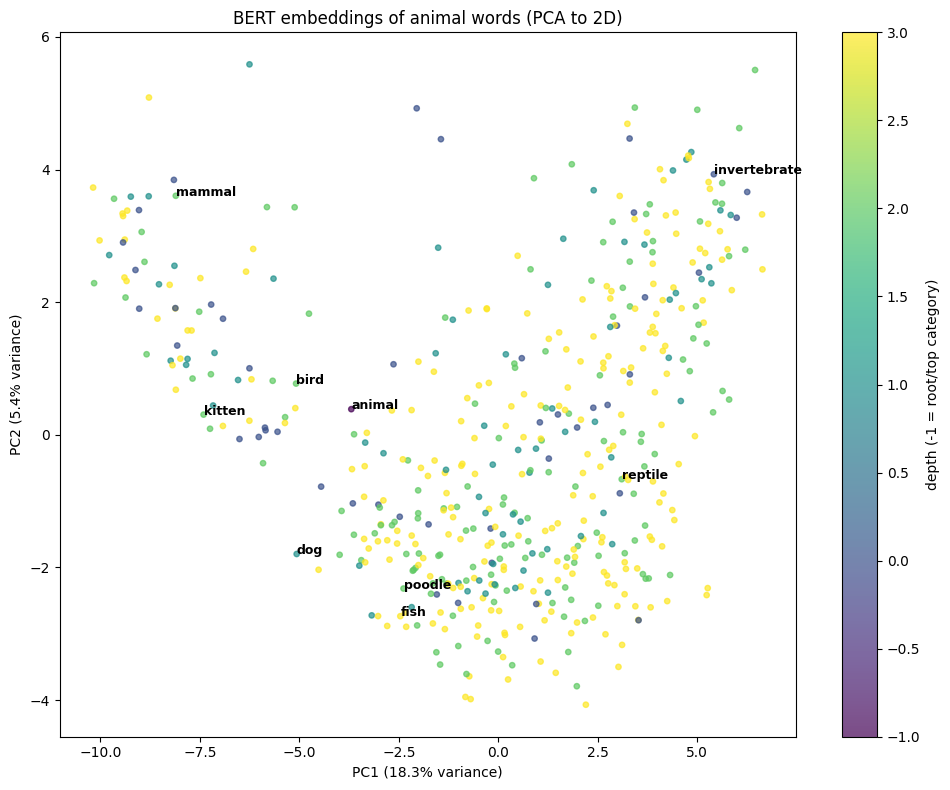

PCA explained variance (2 components): 23.7%


In [24]:
# ── Load data ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'data/animal_pairs.csv'))

with open(os.path.join(DRIVE_BASE, 'embeddings/word_embeddings.pkl'), 'rb') as f:
    embeddings = dict(pickle.load(f))

words = list(embeddings.keys())
vectors = np.array([embeddings[w] for w in words])

# ── Reduce 768 dimensions down to 2, just for visualization ──
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# color each word by the shallowest depth it appears at (as a "specific" word);
# words that only ever appear as a "general" category (like the root "animal")
# get depth -1
depth_map = df.groupby('specific')['depth'].min().to_dict()
depths = np.array([depth_map.get(w, -1) for w in words])

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=depths, cmap='viridis', s=15, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('depth (-1 = root/top category)')
ax.set_title('BERT embeddings of animal words (PCA to 2D)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# ── Label a handful of familiar words ──
highlight = ['animal', 'dog', 'poodle', 'cat', 'kitten', 'bird', 'robin',
             'invertebrate', 'fish', 'reptile', 'mammal']
for w in highlight:
    if w in words:
        i = words.index(w)
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'results/embedding_pca.png'), dpi=150)
plt.show()
print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")

### 7.2 — Depth–Similarity Bar Plot

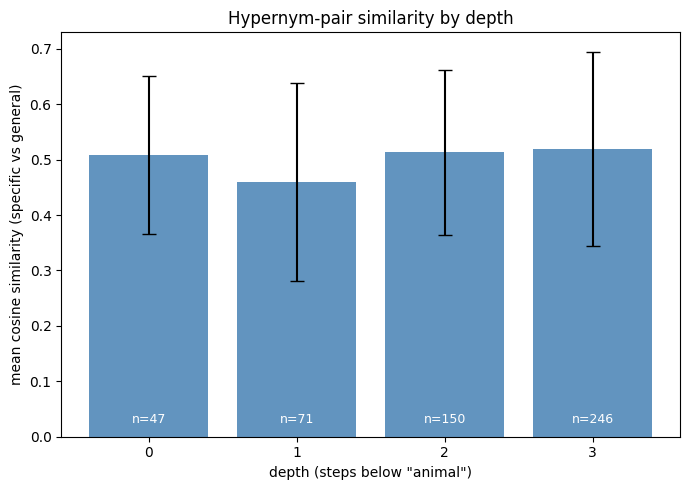

Saved results/depth_similarity.png



,mean,std,count
depth,,,
0,0.508214,0.142786,47
1,0.459011,0.178579,71
2,0.512983,0.148479,150
3,0.519204,0.175665,246


In [25]:
# ── Load pair analysis ──
df = pd.read_csv(os.path.join(DRIVE_BASE, 'results/pair_analysis.csv'))

depth_stats = df.groupby('depth')['similarity'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(depth_stats.index, depth_stats['mean'], yerr=depth_stats['std'], capsize=5,
              color='steelblue', alpha=0.85)

for depth, bar in zip(depth_stats.index, bars):
    count = depth_stats.loc[depth, 'count']
    ax.text(bar.get_x() + bar.get_width() / 2, 0.02, f'n={count}',
            ha='center', va='bottom', fontsize=9, color='white')

ax.set_xlabel('depth (steps below "animal")')
ax.set_ylabel('mean cosine similarity (specific vs general)')
ax.set_title('Hypernym-pair similarity by depth')
ax.set_xticks(depth_stats.index)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'results/depth_similarity.png'), dpi=150)
plt.show()
print('Saved results/depth_similarity.png')
print()
depth_stats

---
## Key Findings

| Metric | BERT (contextual) | GloVe (static) |
|---|---|---|
| Vocabulary coverage | 514/514 pairs (100%) | 397/514 pairs (77.2%) |
| True-pair similarity | 0.508 [0.495, 0.522] | 0.367 [0.337, 0.395] |
| Random-pair similarity | 0.426 [0.415, 0.436] | 0.103 [0.090, 0.116] |
| Effect size (Cohen's *d*) | 0.565 (medium) | 1.147 (large) |
| Offset consistency | 0.209 | 0.224 |

Both models separate true hypernym pairs from random pairs significantly, and neither encodes hypernymy as a single consistent linear direction. GloVe's larger effect size does not survive qualitative inspection: its top-scoring pairs are vocabulary-coverage artifacts, where an out-of-vocabulary modifier collapses a phrase onto its head noun (*apodiform bird* → *bird*, similarity 1.000).